## Stage Contract

Requires:
- parsed SMART-DS or Grid Dataset geometry tables

Produces:
- interactive grid geometry plot for review

Next:
- use the reviewed grid geometry in the flood workflow.


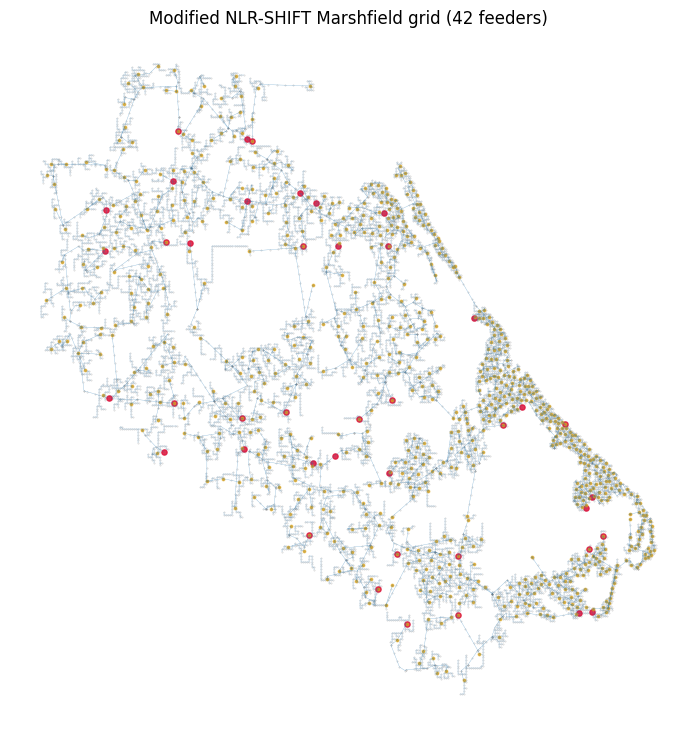

In [5]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString

# Modified NLR-SHIFT grid: Marshfield uses the generated/filtered asset registry, not SMART-DS GeoJSON.
location_name = Path("..").resolve().name
registry_root = Path("../data/power_grid/asset_registry")

lines = pd.read_csv(registry_root / "lines.csv")
buses = pd.read_csv(registry_root / "buses.csv")
feeders = pd.read_csv(registry_root / "feeders.csv")
loads = pd.read_csv(registry_root / "loads.csv")
sources = pd.read_csv(registry_root / "sources.csv")
transformers = pd.read_csv(registry_root / "transformers.csv")

line_geometry = [LineString([(row.from_lon, row.from_lat), (row.to_lon, row.to_lat)]) for row in lines.itertuples(index=False)]
line_grid = gpd.GeoDataFrame(lines, geometry=line_geometry, crs="EPSG:4326")
bus_grid = gpd.GeoDataFrame(buses, geometry=gpd.points_from_xy(buses["lon"], buses["lat"]), crs="EPSG:4326")
load_grid = gpd.GeoDataFrame(loads, geometry=gpd.points_from_xy(loads["lon"], loads["lat"]), crs="EPSG:4326")
source_grid = gpd.GeoDataFrame(sources, geometry=gpd.points_from_xy(sources["lon"], sources["lat"]), crs="EPSG:4326")
transformer_grid = gpd.GeoDataFrame(transformers, geometry=gpd.points_from_xy(transformers["location_lon"], transformers["location_lat"]), crs="EPSG:4326")

ax = line_grid.plot(figsize=(9, 9), linewidth=0.25, color="tab:blue", alpha=0.55)
bus_grid.plot(ax=ax, markersize=0.12, color="black", alpha=0.18)
source_grid.plot(ax=ax, markersize=14, color="crimson", alpha=0.85)
transformer_grid.plot(ax=ax, markersize=3, color="goldenrod", alpha=0.65)
ax.set_title(f"Modified NLR-SHIFT {location_name.title()} grid ({len(feeders)} feeders)")
ax.set_axis_off()

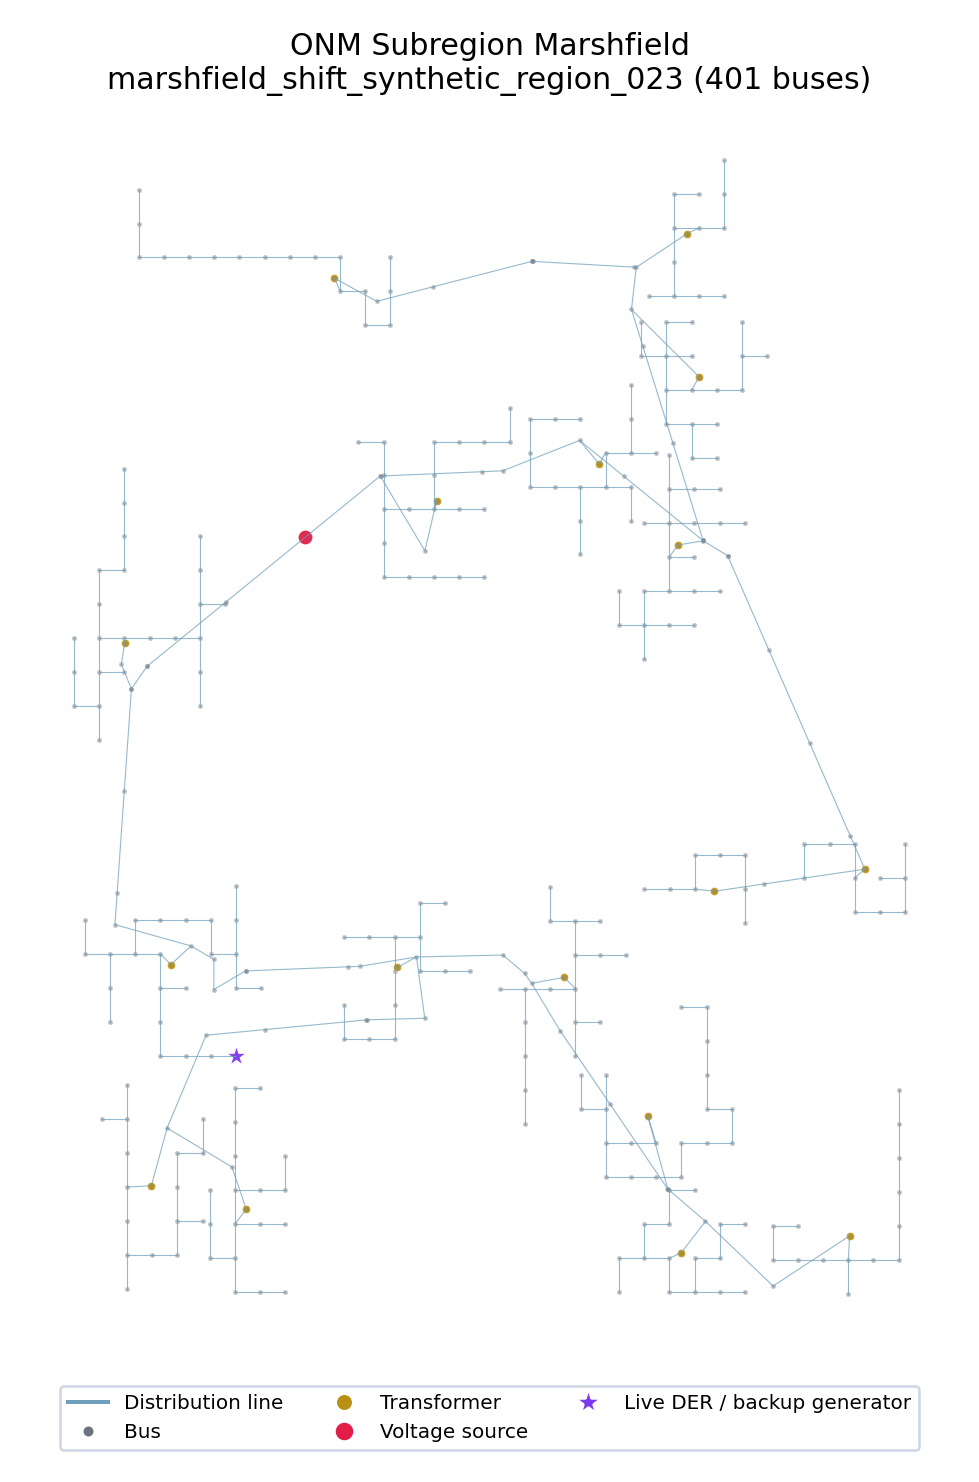

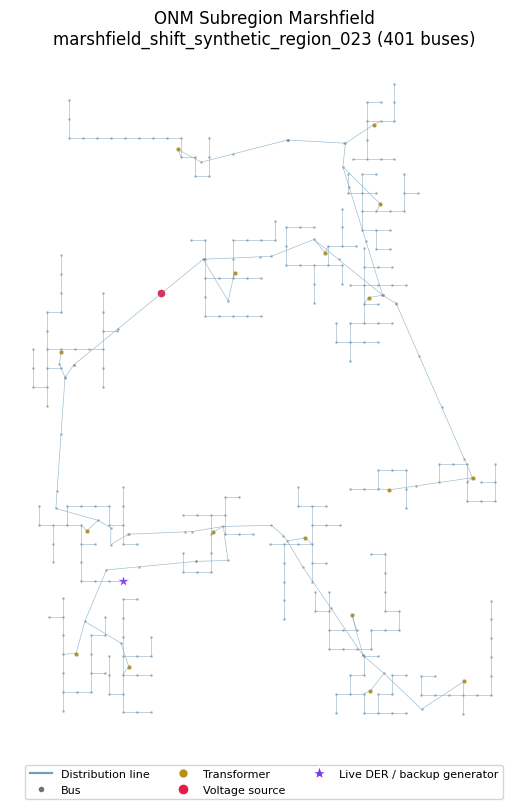

In [7]:
from IPython.display import Image, display
from matplotlib.lines import Line2D

SUBREGION_FEEDERS = ["marshfield_shift_synthetic_region_023"]
subregion_figure_path = Path("../figures/subregion_distribution_net.png")
der_inventory_path = Path("../data/static/power_grid/smart_ds_compat/der_inventory.parquet")

subregion_line_grid = line_grid[line_grid["feeder_id"].astype(str).isin(SUBREGION_FEEDERS)].copy()
subregion_bus_grid = bus_grid[bus_grid["feeder_id"].astype(str).isin(SUBREGION_FEEDERS)].copy()
subregion_source_grid = source_grid[source_grid["feeder_id"].astype(str).isin(SUBREGION_FEEDERS)].copy()
subregion_transformer_grid = transformer_grid[transformer_grid["feeder_id"].astype(str).isin(SUBREGION_FEEDERS)].copy()

if subregion_line_grid.empty:
    raise ValueError(f"No lines found for exported subregion feeders: {SUBREGION_FEEDERS}")

subregion_der_grid = gpd.GeoDataFrame(columns=["der_id", "bus", "genset_kw", "geometry"], geometry="geometry", crs="EPSG:4326")
if der_inventory_path.exists():
    der_inventory = pd.read_parquet(der_inventory_path)
    live_ders = der_inventory[
        der_inventory["bus"].astype(str).str.split("__", n=1).str[0].isin(SUBREGION_FEEDERS)
        & der_inventory["genset_kw"].fillna(0).gt(0)
    ].copy()
    if not live_ders.empty:
        subregion_der_grid = live_ders.merge(
            subregion_bus_grid[["bus", "geometry"]],
            on="bus",
            how="left",
        )
        subregion_der_grid = gpd.GeoDataFrame(subregion_der_grid, geometry="geometry", crs="EPSG:4326").dropna(subset=["geometry"])

ax = subregion_line_grid.plot(figsize=(9, 9), linewidth=0.45, color="#6f9fba", alpha=0.72)
subregion_bus_grid.plot(ax=ax, markersize=1.0, color="#6b7280", alpha=0.38)
subregion_transformer_grid.plot(ax=ax, markersize=11, color="#b99014", alpha=0.86, edgecolor="white", linewidth=0.25)
subregion_source_grid.plot(ax=ax, markersize=36, color="#e11d48", alpha=0.94, edgecolor="white", linewidth=0.5)
if not subregion_der_grid.empty:
    subregion_der_grid.plot(ax=ax, markersize=70, color="#7c3aed", marker="*", alpha=0.95, edgecolor="white", linewidth=0.45)

legend_handles = [
    Line2D([0], [0], color="#6f9fba", lw=1.6, label="Distribution line"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#6b7280", markeredgecolor="none", markersize=4, label="Bus"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#b99014", markeredgecolor="white", markersize=7, label="Transformer"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#e11d48", markeredgecolor="white", markersize=8, label="Voltage source"),
    Line2D([0], [0], marker="*", color="none", markerfacecolor="#7c3aed", markeredgecolor="white", markersize=11, label="Live DER / backup generator"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, framealpha=0.96, facecolor="white", edgecolor="#cbd5e1", fontsize=8)
ax.set_title(
    "ONM Subregion Marshfield\n"
    f"{', '.join(SUBREGION_FEEDERS)} ({len(subregion_bus_grid):,} buses)"
)
ax.set_axis_off()
subregion_figure_path.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(subregion_figure_path, dpi=180, bbox_inches="tight", pad_inches=0.18, facecolor="white")
display(Image(filename=subregion_figure_path))
